In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import Bio
import Bio.Seq

## Import Dataset

In [2]:
df = pd.read_pickle("data/beta_activity.pkl")
df.head()

,sequence,count,response
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,17456,3
1,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,13670,3
2,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,11180,3
3,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,10159,3
4,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,3976,3


In [3]:
# number of sequences
Nseq = len(df)
Nseq

960

In [4]:
# WildType Sequence
WT_DNA = 'ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAGCACGTGCAGAACATATGACCATTGCAGCAGCAATTCATGCACTGGATGCAGATGAAGCAGATGCAATTGTTATGGATATTGTTCCGGATGGTGAACGTGATGCATGGTGGGATGATGAAGGTTTTAGCAGCAGCCCGTTTACCAAAGATGCACATCATGCAGGAGTTGTTGCAACCAGCGTTACCCTGGGTCAGCTGCAGCGTGAACAGGGTGATAAACTGGTTAGCAAAGCAGCAGAATATTTTGGTATTGCCTGCCGTGTTAATGATGGTCTGCGTACCACCCGTTTTGTTCGTCTGTTTAGTGATGCCCTGGATGCCAAACCGCTGACCATTGGTCATGATTATGAAGTTGAATTTCTGCTGGCAACCCGTCGTGTTTATGAACCGTTTGAAGCACCGTTTAACTTTGCACCGCATTGTGGCGATGTTAGCTATGGTCGTGATACCGTTAATTGGCCTCTGAAACATAGCTTTCCGCGTCAGCTGGGTGGTTTTCTGACCATTCAGGGTGCAGATAATGATGCCGGTATGGTTATGTGGGATAATCGTCCGGAAAGCCGTGCAGCGCTGGATGAAATGCATGCAGAATATCGTGAAACCGGTGCAATTGCCGCACTGGAACGTGCAGCCAAAATCATGCTGAAACCGCAGCCTGGCCAGCTGACACTGTTTCAGAGCAAAAATCTGCATGCCATTGAACGTTGTACCAGCACCCGTCGTACCATGGGTCTGTTTCTGATTCATACCGAAGATGGTTGGCGTATGTTTGATTGA'
WT = Bio.Seq.Seq(WT_DNA).translate()
WT

Seq('MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDGERDAWWDD...FD*', HasStopCodon(ExtendedIUPACProtein(), '*'))

In [5]:
# Length of a sequence
N = len(df.iloc[0].sequence)
N

274

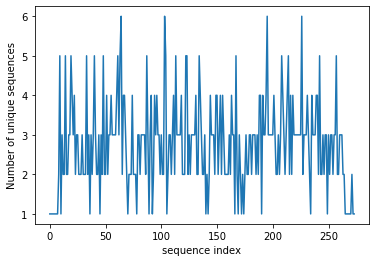

In [6]:
# Number of unique mutations at each index
num_unique = np.array([len(df.sequence.str.get(i).unique()) for i in range(N)])
plt.plot(num_unique)
plt.xlabel("sequence index")
plt.ylabel("Number of unique sequences");

In [7]:
len(df.sequence.unique())

900

In [8]:
len(df)

960

In [9]:
# location of the first stop sequence
df["first_stop"] = df.sequence.str.find("*")
print((df.first_stop != (N-1)).sum())
# print out wherever we have a stop in the middle
df[df.first_stop != (N-1)]

43


,sequence,count,response,first_stop
15,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,1631,3,122
18,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,1263,3,122
11,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,101,0,84
26,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,38,0,214
30,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,36,0,84
40,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,32,0,195
92,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,22,0,91
101,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,21,0,212
133,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,17,0,167
146,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,16,0,170


In [10]:
df[df.sequence == WT]

,sequence,count,response,first_stop
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,17456,3,273
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,29398,2,273
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,1124,1,273
1,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,781,0,273


In [11]:
df_nostop = df[df.first_stop == (len(WT) -1)].drop(columns=['first_stop'])
df_nostop.head()

,sequence,count,response
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,17456,3
1,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,13670,3
2,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,11180,3
3,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,10159,3
4,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,3976,3


In [12]:
# Replace non-unique sequences with their response category with the highest count
df_unique = df_nostop.sort_values('count', ascending=False).groupby('sequence').head(1).reset_index(drop=True)
df_unique.head()

,sequence,count,response
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,29398,2
1,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,20885,2
2,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,13670,3
3,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,10801,2
4,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,6016,2


In [13]:
df_unique[["sequence", "response"]].groupby("response").count()

,sequence
response,
0,615
1,178
2,53
3,11


In [14]:
# Where is WT in this dataframe
# It should be at the top
df_unique[df_unique.sequence==WT]

,sequence,count,response
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,29398,2


## Ordinal regression

In [15]:
from sklearn.preprocessing import OneHotEncoder # to create the design matrix
import mord

In [16]:
design_cols = df_unique.sequence.apply(lambda x: pd.Series(list(x)))

# one hot encode the design columns to get a design matrix
enc = OneHotEncoder(
    drop=None, # don't drop columns 
    sparse=False ) # setting to False for now
X = enc.fit_transform(design_cols)
print(X.shape)
X

(857, 725)


array([[1., 1., 1., ..., 0., 1., 1.],
       [1., 1., 1., ..., 0., 1., 1.],
       [1., 1., 1., ..., 0., 1., 1.],
       ...,
       [1., 1., 1., ..., 0., 1., 1.],
       [1., 1., 1., ..., 0., 1., 1.],
       [1., 1., 1., ..., 0., 1., 1.]])

In [17]:
enc.get_feature_names().size

725

In [18]:
y = df_unique.response.to_numpy()

In [19]:
# Try out model with alpha = 1.0
model = mord.LogisticAT(alpha=1.0)
model.fit(X, y)
model.score(X, y)

-0.13885647607934656

In [20]:
from sklearn.model_selection import GridSearchCV, cross_val_score

In [21]:
alphas = np.logspace(-6, 2, 10) # search space for regularization params
grid_cv = GridSearchCV(estimator=model, param_grid=dict(alpha=alphas), cv=5, iid='deprecated')
grid_cv.fit(X, y)

GridSearchCV(cv=5, error_score='raise-deprecating',
             estimator=LogisticAT(alpha=1.0, max_iter=1000, verbose=0),
             iid='deprecated', n_jobs=None,
             param_grid={'alpha': array([1.00000000e-06, 7.74263683e-06, 5.99484250e-05, 4.64158883e-04,
       3.59381366e-03, 2.78255940e-02, 2.15443469e-01, 1.66810054e+00,
       1.29154967e+01, 1.00000000e+02])},
             pre_dispatch='2*n_jobs', refit=True, return_train_score=False,
             scoring=None, verbose=0)

In [22]:
grid_cv.best_score_

-0.3628938156359393

In [23]:
# regularization parameter picked by CV
grid_cv.best_params_

{'alpha': 0.02782559402207126}

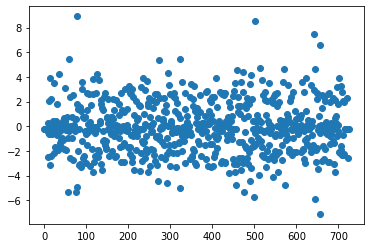

In [24]:
best_coefs = grid_cv.best_estimator_.coef_
plt.plot(best_coefs, 'o')

In [25]:
best_results = pd.DataFrame({'feature':enc.get_feature_names(), 'coef':best_coefs})

In [26]:
best_results.sort_values('coef', ascending=False).head(10)

,feature,coef
77,x33_K,8.920439
501,x191_S,8.518759
643,x238_Q,7.453745
655,x242_K,6.557181
322,x122_I,5.470096
59,x25_T,5.441821
273,x104_G,5.386484
513,x195_L,4.730882
645,x239_F,4.645217
570,x214_G,4.609162


In [27]:
def show_design_response(col_num):
    return pd.DataFrame({'aa':design_cols[col_num], 'response':y}).groupby(['aa', 'response']).size()
show_design_response(33)

aa  response
D   0             2
    1             1
E   0           601
    1           177
    2            53
    3            10
G   0             7
K   0             1
    3             1
V   0             4
dtype: int64

In [28]:
show_design_response(191)

aa  response
A   1             1
G   0           614
    1           176
    2            53
    3             9
R   0             1
S   1             1
    3             2
dtype: int64

In [29]:
best_results.sort_values('coef', ascending=True).head(10)

,feature,coef
657,x242_R,-7.107298
644,x238_V,-5.914750
500,x191_R,-5.723460
76,x33_G,-5.370373
57,x25_A,-5.338948
475,x182_S,-5.293462
324,x122_R,-5.011674
78,x33_V,-4.958902
457,x175_H,-4.793514
572,x214_V,-4.736653


In [30]:
show_design_response(238)

aa  response
L   0           613
    1           178
    2            53
    3             9
Q   0             1
    3             2
V   0             1
dtype: int64

In [31]:
show_design_response(214)

aa  response
E   0           609
    1           178
    2            51
    3            11
G   0             2
    2             2
K   0             1
V   0             3
dtype: int64

In [32]:
pd.set_option('display.max_rows', 1000)
best_results

,feature,coef
0,x0_M,-0.241935
1,x1_Q,-0.241935
2,x2_H,-0.241935
3,x3_T,-0.241935
4,x4_Y,-0.241935
5,x5_P,-0.241935
6,x6_A,-0.241935
7,x7_Q,-0.241935
8,x8_L,0.257705
9,x8_P,-0.499640
